# Evaluación Parcial 1: Análisis de Rotación de Clientes (Telco)

**Estudiantes:**


*   Bastian Roman
*   Vicente Contreras
*   Ignacio Gomez



**Asignatura:** Programación para la Ciencia de Datos

**Pregunta de Negocio:** ¿Podemos predecir qué clientes tienen más probabilidad de abandonar la empresa basándonos en su comportamiento de facturación y tipo de contrato, antes de que sea demasiado tarde?

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


GitHub: https://github.com/Lucem-nacho/Proyecto-Rotaci-n-de-clientes-de-telecomunicaciones.git

**Diccionario de Variables Clave:**
* `gender`: Género del cliente (Male/Female).
* `SeniorCitizen`: Si el cliente es adulto mayor (0: No, 1: Sí).
* `Partner`: Si el cliente tiene pareja (Yes/No).
* `tenure`: Meses que el cliente ha permanecido en la compañía.
* `InternetService`: Tipo de servicio de internet (DSL, Fiber optic, No).
* `Contract`: Tipo de contrato (Month-to-month, One year, Two year).
* `PaperlessBilling`: Si el cliente usa facturación electrónica (Yes/No).
* `PaymentMethod`: Método de pago.
* `MonthlyCharges`: Monto facturado mensualmente.
* `gender`: Género del cliente (Male/Female).
* `TotalCharges`: Monto total facturado al cliente.
* `Churn`: **Variable Objetivo.** Indica si el cliente canceló el servicio en el último mes ('Yes' o 'No').

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Forzar configuración para evitar bloqueo de hilos
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Configuración visual moderna (Sin %matplotlib inline)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("Listo. Ya puedes trabajar.")

# Configuración de gráficos profesional
sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline

Listo. Ya puedes trabajar.


In [9]:
# Carga de datos crudos
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# TotalCharges viene como 'object' por espacios en blanco. 
# Si no lo convertimos a numérico ahora, el mapa de calor no detectará los nulos.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (7043, 21)


**Identificación de Problemas de Integridad**

Identificamos que TotalCharges es de tipo object a pesar de contener datos numéricos. Esto se debe a espacios en blanco en registros con tenure igual a 0.

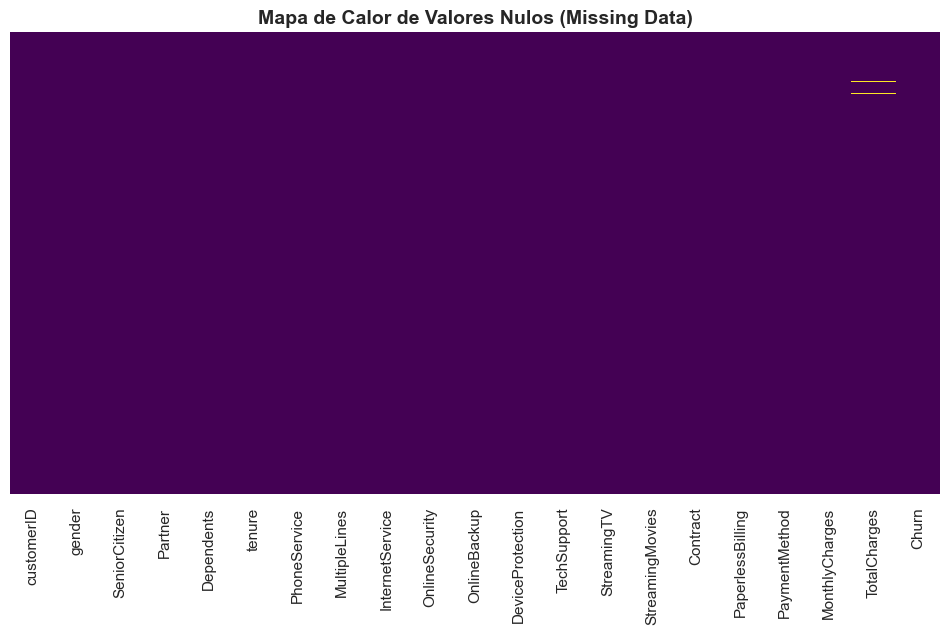

Conteo de valores nulos por columna:
TotalCharges    11
dtype: int64


In [10]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Nulos (Missing Data)', fontweight='bold', fontsize=14)
plt.show()

# Contabilizar nulos exactos
print("Conteo de valores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Eliminamos los nulos confirmados para continuar el análisis
df.dropna(inplace=True)

C:\Users\basti\AppData\Local\Temp\ipykernel_8396\830914751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


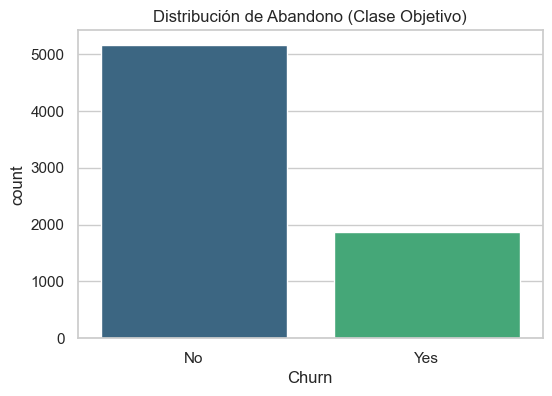

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de Abandono (Clase Objetivo)')
plt.show()

Distribuciones numéricas


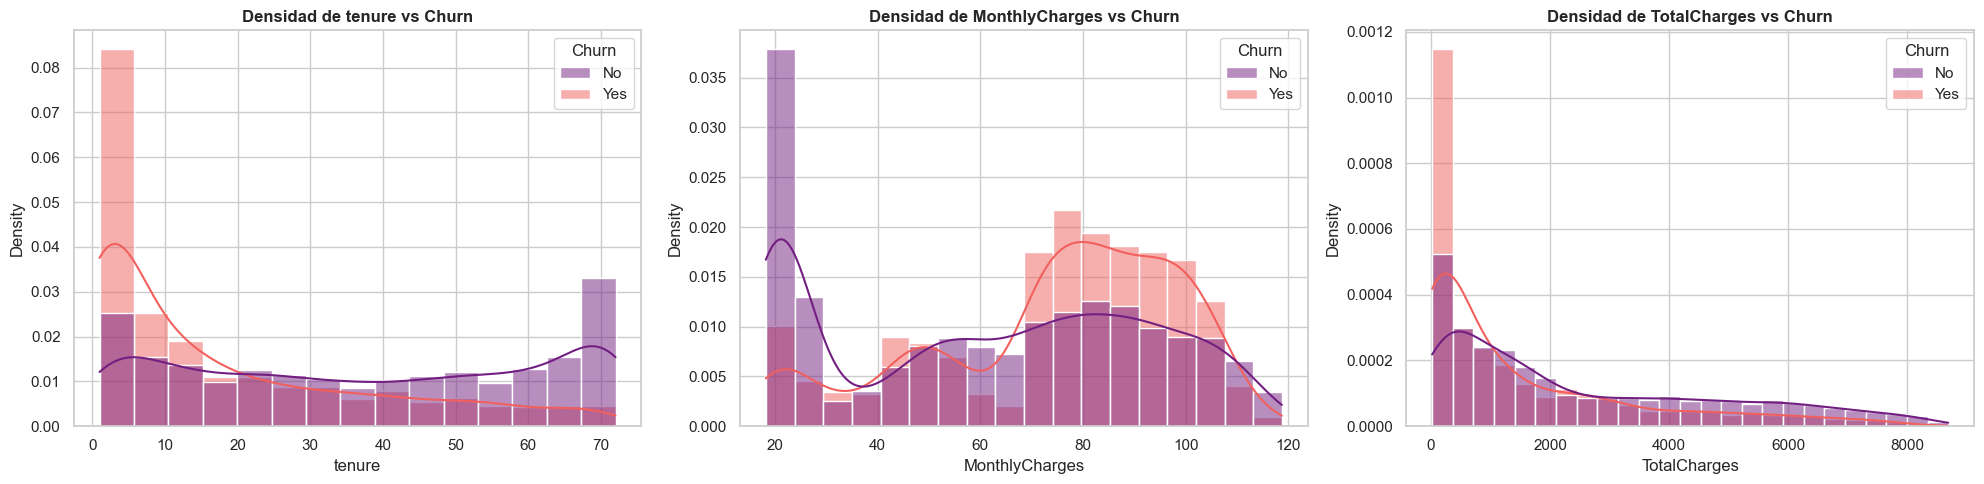

distribuciones categoricas


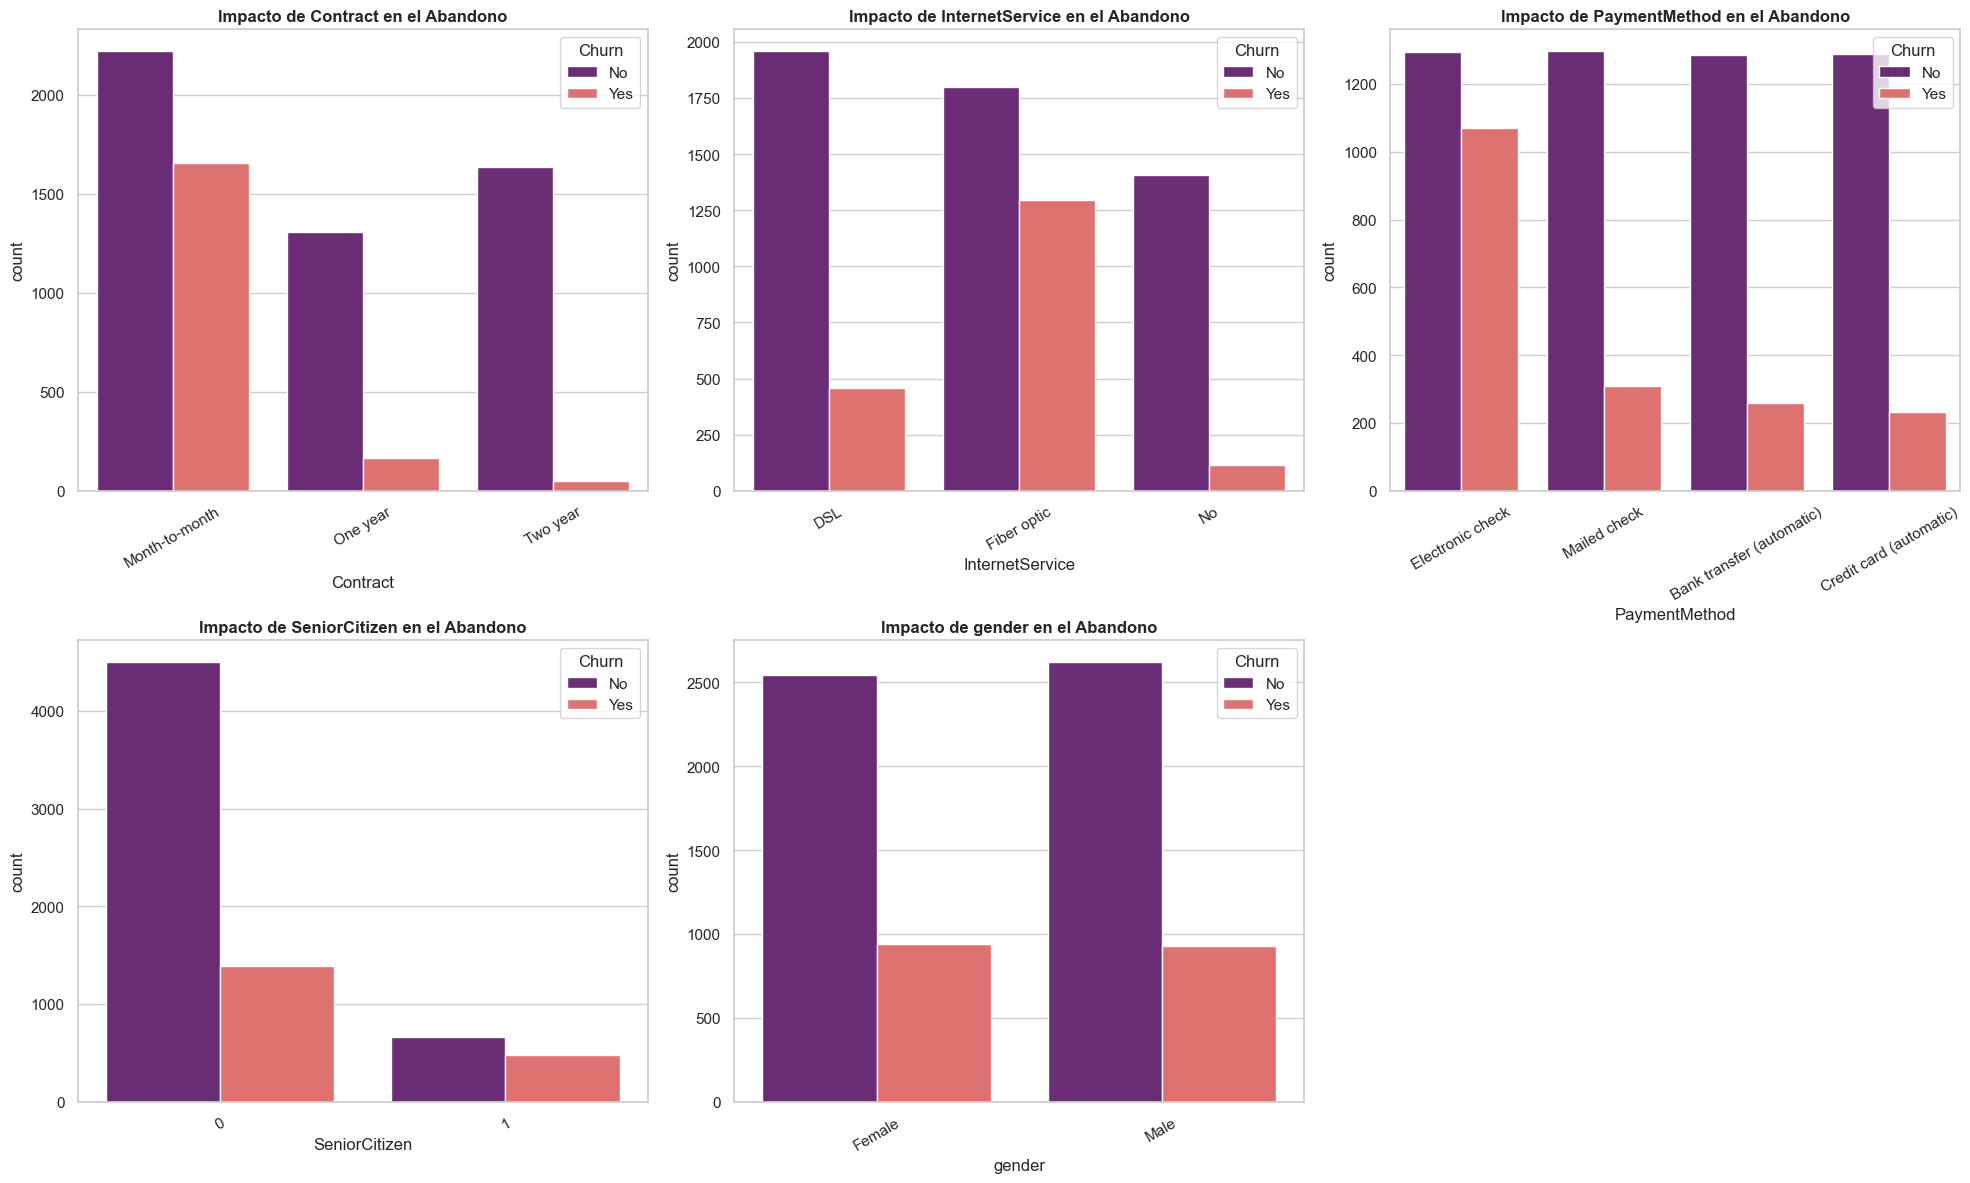

In [12]:
def plot_telco_analysis(df, target_col='Churn'):
    # PREPARACIÓN PREVIA: Aseguramos que TotalCharges sea numérica para el gráfico
    df_plot = df.copy()
    df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

    # 1. Variables Numéricas
    print("Distribuciones numéricas")
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for i, col in enumerate(num_cols):
        sns.histplot(data=df_plot, x=col, hue=target_col, kde=True, ax=axes[i],
                     stat='density', common_norm=False, palette='magma', alpha=0.5)
        axes[i].set_title(f'Densidad de {col} vs {target_col}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    # 2. Variables Categóricas Clave
    print("distribuciones categoricas")
    # Seleccionamos las que más influyen según la teoría de negocio
    cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'gender'] # Added 'gender'

    # Adjusted grid for 5 plots (n_rows=2, n_cols=3) to accommodate 'gender'
    n_rows = 2
    n_cols = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12)) # Adjusted figure size
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        sns.countplot(data=df_plot, x=col, hue=target_col, ax=axes[i], palette='magma')
        axes[i].set_title(f'Impacto de {col} en el Abandono', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=30)

    # Hide any unused subplots if the number of categorical columns is less than n_rows * n_cols
    for i in range(len(cat_cols), n_rows * n_cols):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Llamada a la función con tu DataFrame filtrado
plot_telco_analysis(df)

Calculando límites IQR y aplicando recorte (Capping) a: ['tenure', 'MonthlyCharges', 'TotalCharges']
Registros originales: 7032
Registros tras el tratamiento: 7032

--------------------------------------------------


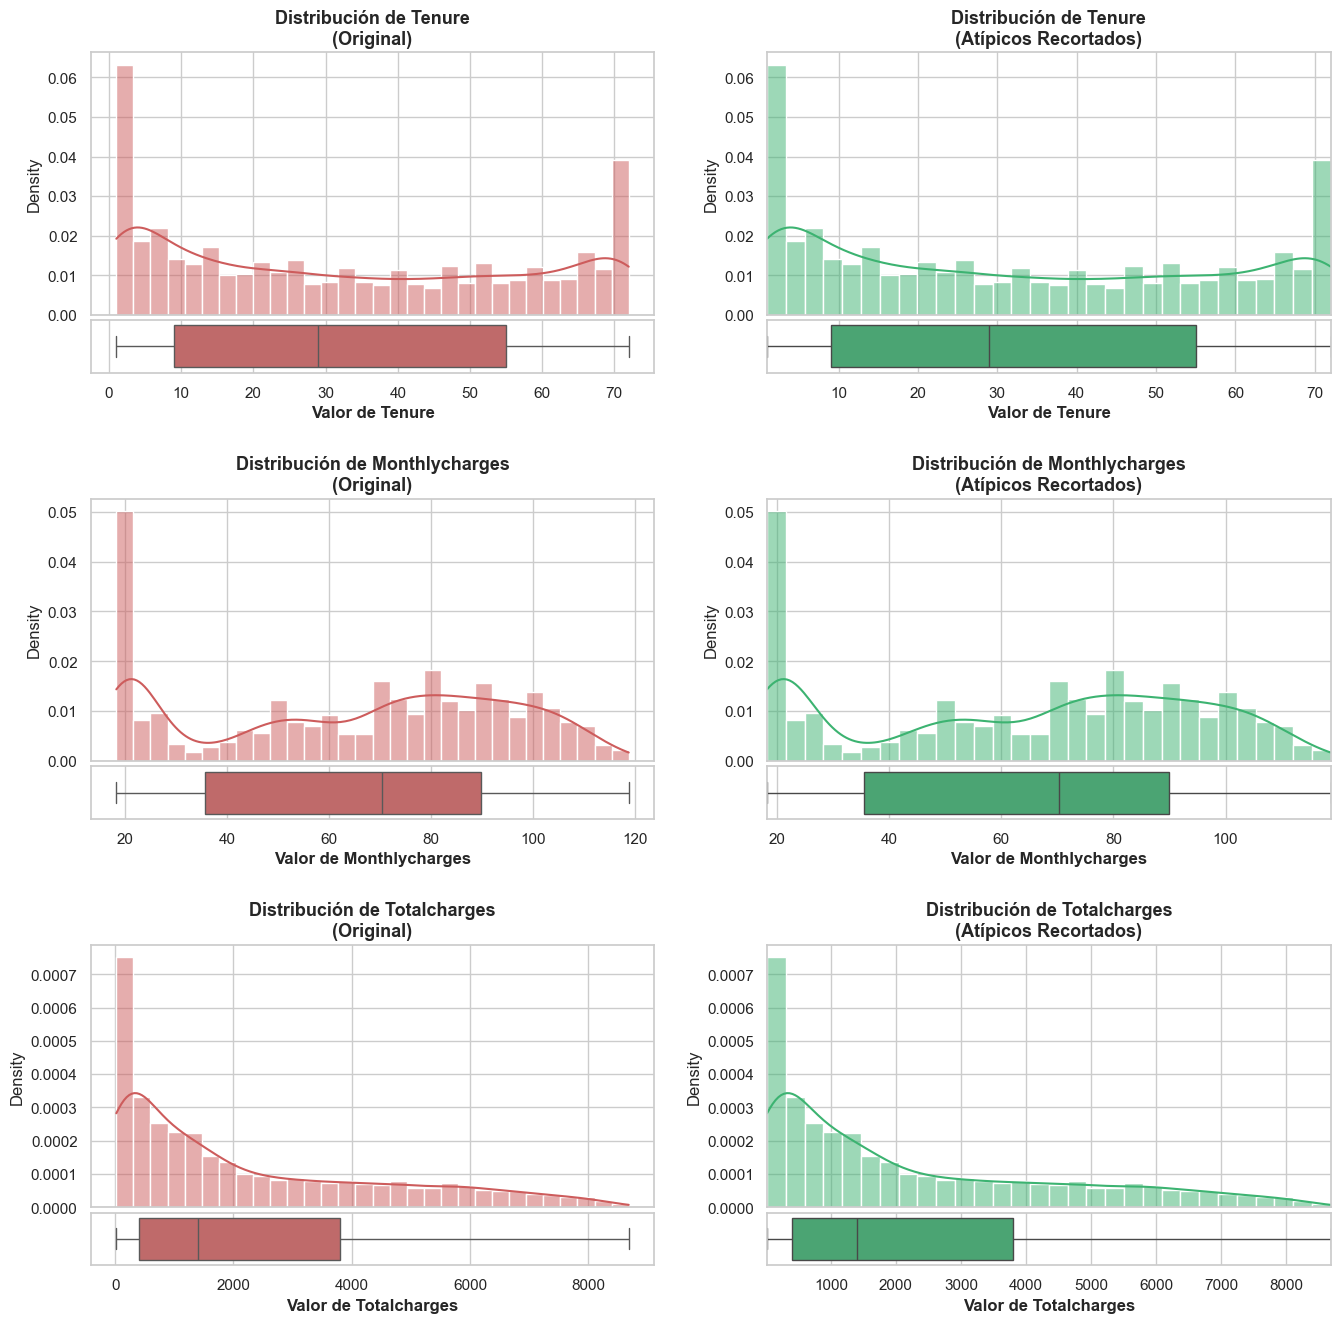

In [13]:
# 1. Definimos las variables numéricas específicas de tu análisis
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Creamos copia y aplicamos Capping a estas columnas
df_sin_outliers = df.copy()

print(f"Calculando límites IQR y aplicando recorte (Capping) a: {numerical_cols}")
for col in numerical_cols:
    # Aseguramos que sea numérico para el cálculo
    df_sin_outliers[col] = pd.to_numeric(df_sin_outliers[col], errors='coerce')

    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Aplicamos el recorte (Capping) usando np.clip
    df_sin_outliers[col] = np.clip(df_sin_outliers[col], lower_bound, upper_bound)

print(f"Registros originales: {len(df)}")
print(f"Registros tras el tratamiento: {len(df_sin_outliers)}\n")
print("-" * 50)

# 3. Visualización Dinámica Avanzada con Ejes Ajustados
fig, axs = plt.subplots(len(numerical_cols), 2, figsize=(16, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    nombre_columna = col.capitalize()
    data_orig = pd.to_numeric(df[col], errors='coerce').dropna()
    data_cap = df_sin_outliers[col].dropna()

    # COLUMNA IZQUIERDA: DATOS ORIGINALES
    ax_hist_orig = axs[i, 0]
    ax_hist_orig.set_title(f'Distribución de {nombre_columna}\n(Original)', fontweight='bold', fontsize=13)
    sns.histplot(data_orig, bins=30, kde=True, ax=ax_hist_orig, color='indianred', stat='density')
    ax_hist_orig.set_xlabel('')
    ax_hist_orig.tick_params(labelbottom=False)

    ax_box_orig = ax_hist_orig.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=data_orig, ax=ax_box_orig, color='indianred', fliersize=3)
    ax_box_orig.set_xlim(ax_hist_orig.get_xlim())
    ax_box_orig.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

    # COLUMNA DERECHA: DATOS RECORTADOS (CAPPING) - EJE AJUSTADO
    ax_hist_cap = axs[i, 1]
    ax_hist_cap.set_title(f'Distribución de {nombre_columna}\n(Atípicos Recortados)', fontweight='bold', fontsize=13)
    sns.histplot(data_cap, bins=30, kde=True, ax=ax_hist_cap, color='mediumseagreen', stat='density')
    ax_hist_cap.set_xlabel('')
    ax_hist_cap.tick_params(labelbottom=False)

    ax_box_cap = ax_hist_cap.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=data_cap, ax=ax_box_cap, color='mediumseagreen', fliersize=3)

    # AJUSTE: Limitamos el eje X al rango de los datos ya recortados para mejorar la visibilidad
    ax_hist_cap.set_xlim(data_cap.min(), data_cap.max())
    ax_box_cap.set_xlim(ax_hist_cap.get_xlim())
    ax_box_cap.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

plt.subplots_adjust(hspace=0.7)
plt.show()

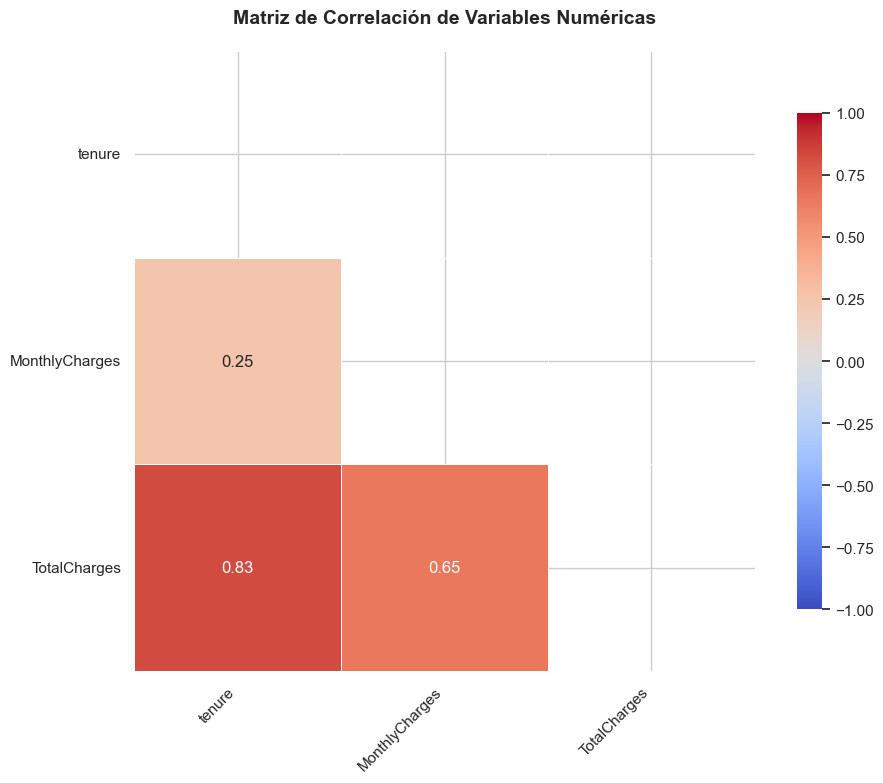

In [14]:
# 1. Seleccionar solo las variables numéricas de interés del DataFrame
num_cols_corr = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df_sin_outliers[num_cols_corr].corr()

# --- EL TRUCO VISUAL: Crear una máscara para el triángulo superior ---
# np.triu_indices_from devuelve los índices del triángulo superior
mask = np.zeros_like(matriz_correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 3. Configurar la visualización
plt.figure(figsize=(10, 8))

# Generar un Heatmap aplicando la máscara (mask=mask)
sns.heatmap(matriz_correlacion,
            mask=mask,               # <--- Aplicamos la máscara aquí
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={"shrink": .8})

plt.title("Matriz de Correlación de Variables Numéricas", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Conclusiones del Análisis Multivariado:**

* **Calidad de Datos:** El mapa de calor reveló nulos únicamente en TotalCharges (11 registros correspondientes a clientes nuevos con tenure=0). Fueron depurados.

* **Outliers:** Los boxplots indican una ausencia de valores atípicos severos en la facturación, lo que facilita el escalado de datos para modelos predictivos.

* **Distribución Numérica:** El histograma de MonthlyCharges confirma que altas tarifas mensuales concentran una mayor densidad de abandonos.

* **Frecuencias Categóricas:** La ejecución automatizada de barras confirma la hipótesis de negocio: el contrato "Month-to-month" y el servicio de internet por fibra óptica son los principales focos de rotación (Churn = Yes).